In [8]:
import numpy as np
import matplotlib.pyplot as plt

# (a)

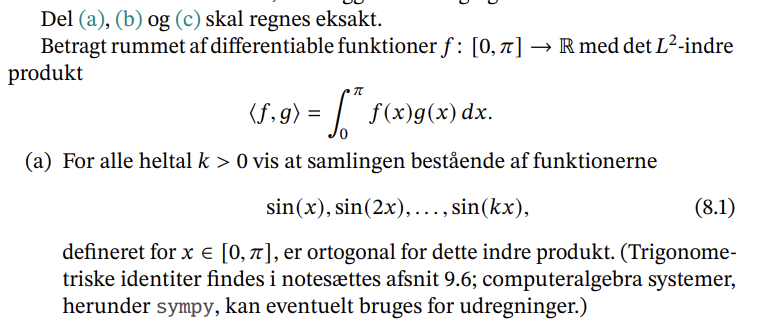

Lad $f(x) = \sin(ax)$ og $g(x) = \sin(bx)$, for $a, b \in \mathbb{N} \land a \neq b$

$$\langle f, g \rangle = \int_0^\pi f(x)g(x) dx = \int_0^\pi \sin(ax)\sin(bx)$$

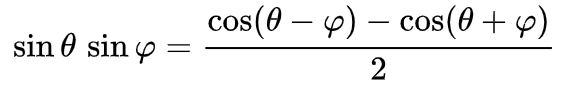

$$= \frac{1}{2} \int_0^\pi \cos((a - b)x)-\cos((a+b)x)$$

$$= \frac{1}{2} [ \frac{1}{a+b} \sin((a+b)x) - \frac{1}{a-b} \sin((a-b)x)]_0^\pi$$

Vi ved at sinus af en hver heltals multipel af $\pi$ eller $0$ er lig 0. Dermed har vi at:

$$= 0$$

$\square$

# (b)

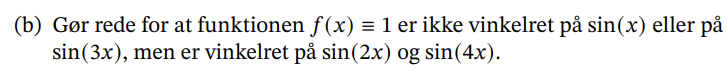

Lad $f(x) = \sin(ax)$ og $g(x) = 1$, for $a \in \mathbb{N}$

$$\langle f, g \rangle = \int_0^\pi f(x)g(x) dx = \int_0^\pi \sin(ax)$$

$$= [-\frac{1}{a} \cos(ax)]_0^\pi = -\frac{(-1)^{a}}{a} + \frac{1}{a}$$

Her kan vi se at hvis $a$ er lige, så vil vi få $-1/a + 1/a = 0$. Hvis den ikke er lige, og dermed ulige, så får vi at: $1/a+1/a = 2/a \neq 0$.

Dermed er sinusfunktionen kun vinkelret på $1$ når deres vinkelfrekvens er et lige heltal.

# (c)

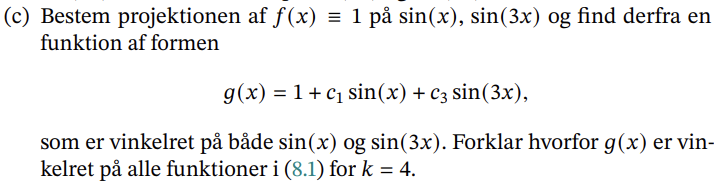

Her vil vores skalarer $c_1$ og $c_3$ være givet ved $\frac{\langle 1, sin(ax) \rangle}{\langle sin(ax), sin(ax) \rangle}$.

Vi har allerede

Her viser det sig at at vores to konstanter er:

$$c_1 = -\frac{4}{\pi}$$
$$c_3 = -\frac{4}{3\pi}$$

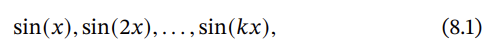

Vi beviste i b) at 1 er vinkelret på alle sinusider med lige heltal som vinkelfrekvenser. Dermed må g(x) allerede være vinkelret på $\sin(2x)$ og $\sin(4x)$

# (d)

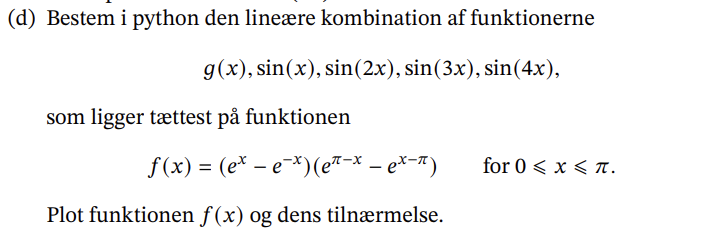

Projektionen af funktionen $f$ ned på samlingen af funktioner, vil være den lineære kombination af funktionerne som ligger tættest på $f$.

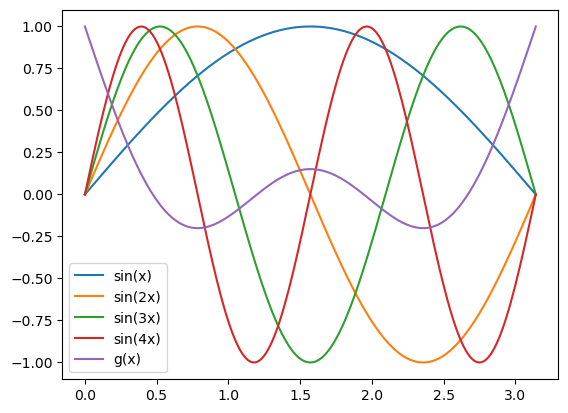

In [9]:
# Angivelse af funktioner
x, h = np.linspace(0, np.pi, 200, retstep=True)
sin1 = np.sin(x)
sin2 = np.sin(2*x)
sin3 = np.sin(3*x)
sin4 = np.sin(4*x)

g = 1 - 4/np.pi * np.sin(x) - 4/(3*np.pi) * np.sin(3*x)

samling = [sin1, sin2, sin3, sin4, g]

plt.plot(x, sin1, label='sin(x)')
plt.plot(x, sin2, label='sin(2x)')
plt.plot(x, sin3, label='sin(3x)')
plt.plot(x, sin4, label='sin(4x)')
plt.plot(x, g, label='g(x)')

plt.legend()

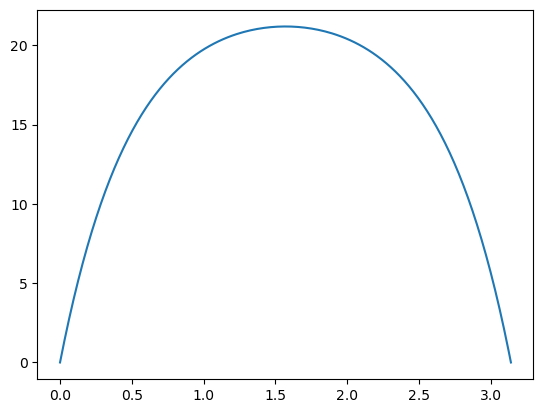

In [10]:
# Angivelse af f
f = (np.exp(x)-np.exp(-x))*(np.exp(np.pi-x)-np.exp(x-np.pi))

plt.plot(x, f)

In [11]:
# Definition af simpson integral
def trapz(f, h):
    # Sum af alle gennemsnitshøjder af de 2 søjler for hver box
    totalAvgBoxHeight = 1/2*(f[0] + 2*np.sum(f[1:-1]) + f[-1])
    TrapzBoxInt = totalAvgBoxHeight * h
    return TrapzBoxInt

def indre_produkt(f, g, h):
    return trapz(f*g, h)

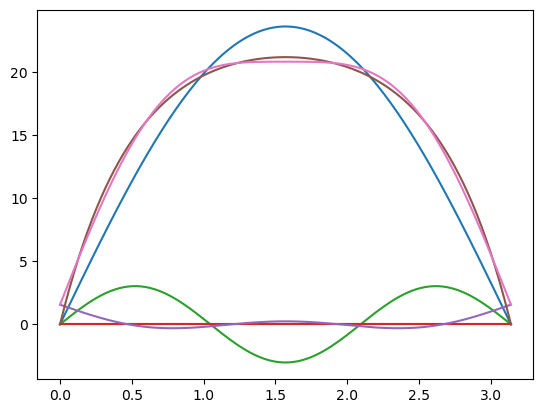

In [12]:
tilnærmelse = 0

for func in samling:
    plt.plot(x, indre_produkt(func, f, h)/indre_produkt(func, func, h) * func)
    tilnærmelse += indre_produkt(func, f, h)/indre_produkt(func, func, h) * func

plt.plot(x, f)
plt.plot(x, tilnærmelse)

In [13]:
import sympy as sp

x = sp.symbols('x')
n, m = sp.symbols('n m', integer=True)

integral = sp.integrate(sp.sin(n*x)*sp.sin(m*x), (x, 0, sp.pi))
integral

Piecewise((0, Eq(m, 0) | Eq(n, 0) | (Eq(m, 0) & Eq(n, 0)) | (Eq(m, 0) & Eq(m, n) & Eq(n, 0)) | (Eq(m, 0) & Eq(n, 0) & Eq(m, -n)) | (Eq(m, 0) & Eq(m, n) & Eq(n, 0) & Eq(m, -n))), (-pi/2, Eq(m, -n) | (Eq(m, 0) & Eq(m, -n)) | (Eq(m, n) & Eq(m, -n)) | (Eq(n, 0) & Eq(m, -n)) | (Eq(m, 0) & Eq(m, n) & Eq(m, -n)) | (Eq(m, n) & Eq(n, 0) & Eq(m, -n))), (pi/2, Eq(m, n) | (Eq(m, 0) & Eq(m, n)) | (Eq(m, n) & Eq(n, 0))), (0, True))